In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
INPUT_FILE = Path('earnings_sentiment_vader.csv')

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        'Run code-15-Vader-Sentiment.ipynb first to create earnings_sentiment_vader.csv.'
    )

df = pd.read_csv(INPUT_FILE)
df.head()


,date,exchange,q,ticker,transcript,compound,neg,neu,pos,label
0,"Aug 27, 2020, 9:00 p.m. ET",NASDAQ: BILI,2020-Q2,BILI,"Prepared Remarks:\nOperator\nGood day, and wel...",1.0000,0.012,0.812,0.177,POS
1,"Jul 30, 2020, 4:30 p.m. ET",NYSE: GFF,2020-Q3,GFF,Prepared Remarks:\nOperator\nThank you for sta...,1.0000,0.017,0.829,0.154,POS
2,"Oct 23, 2019, 5:00 p.m. ET",NASDAQ: LRCX,2020-Q1,LRCX,Prepared Remarks:\nOperator\nGood day and welc...,1.0000,0.015,0.819,0.166,POS
3,"Nov 6, 2019, 12:00 p.m. ET",NASDAQ: BBSI,2019-Q3,BBSI,"Prepared Remarks:\nOperator\nGood day, everyon...",1.0000,0.018,0.866,0.117,POS
4,"Aug 7, 2019, 8:30 a.m. ET",NASDAQ: CSTE,2019-Q2,CSTE,Prepared Remarks:\nOperator\nGreetings and wel...,0.9999,0.020,0.852,0.128,POS


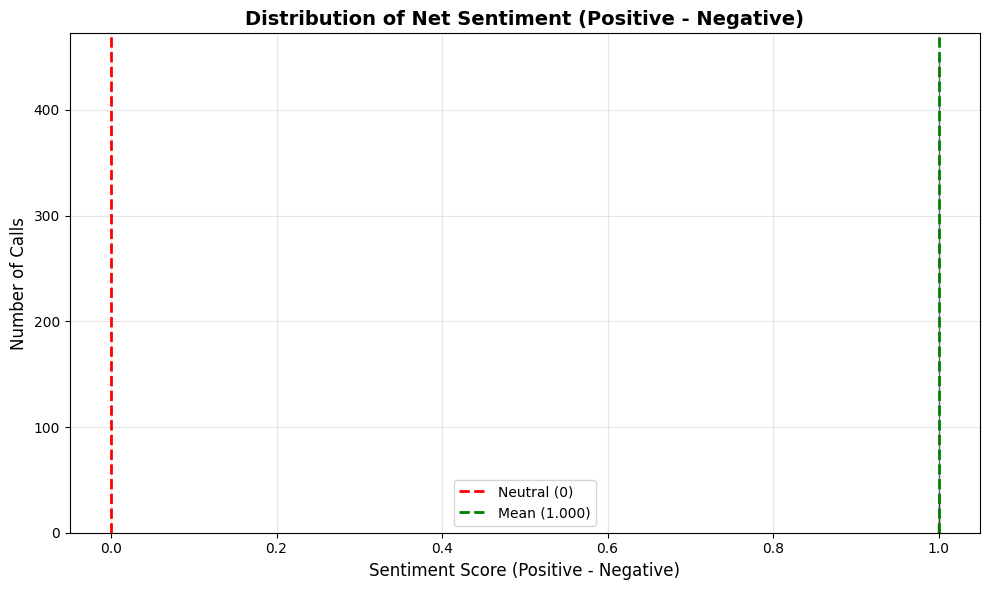

In [4]:
# ============================================
# ENHANCED HISTOGRAM
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
df['compound'].hist(
    bins=20 if len(df) > 20 else 5,  # Adjust bins based on data
    color='skyblue',
    edgecolor='black',
    alpha=0.7,
    ax=ax
)

# Add vertical line at zero (neutral sentiment)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral (0)')

# Add mean line
mean_sentiment = df['compound'].mean()
ax.axvline(x=mean_sentiment, color='green', linestyle='--', linewidth=2,
           label=f'Mean ({mean_sentiment:.3f})')

# Labels and title
ax.set_title('Distribution of Net Sentiment (Positive - Negative)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Score (Positive - Negative)', fontsize=12)
ax.set_ylabel('Number of Calls', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig("net_sentiment_hist_VADER.png", dpi=300, bbox_inches="tight")

plt.show()


/var/folders/jv/6xp73vlj20lc3z22_6wh_1_m0000gn/T/ipykernel_88655/3113683976.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(sentiment_data, labels=['Positive', 'Negative', 'Neutral'])


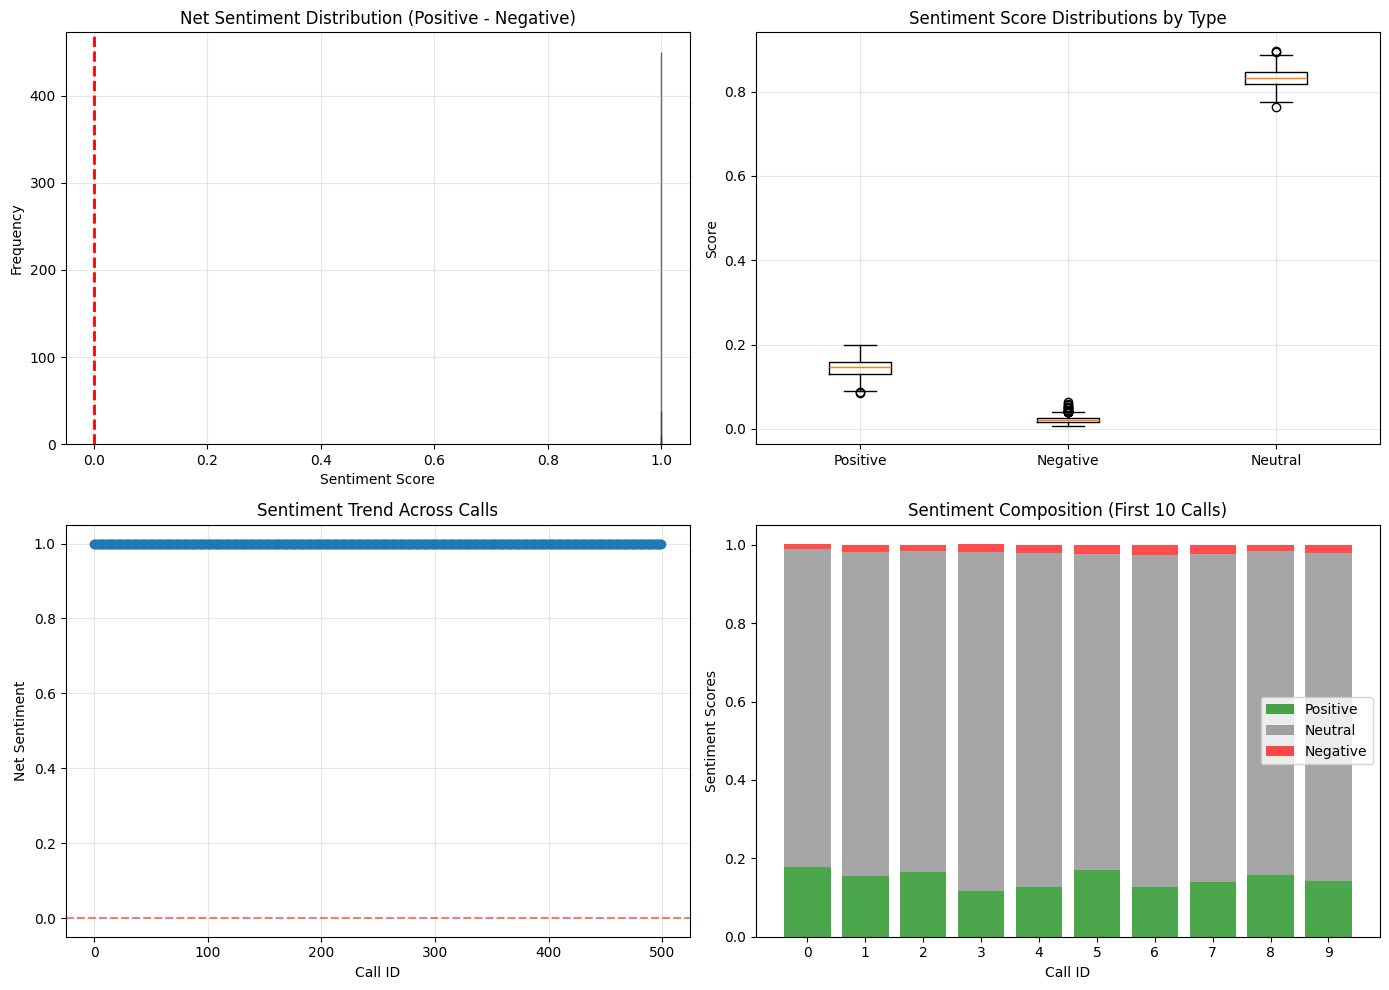

In [5]:
x_call = df.index

# ============================================
# MULTIPLE VISUALIZATIONS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3.1 Histogram of diff
axes[0, 0].hist(df['compound'], bins=20, color='skyblue',
                edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Net Sentiment Distribution (Positive - Negative)')
axes[0, 0].set_xlabel('Sentiment Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 3.2 Box plot of all sentiment types
sentiment_data = df[['pos', 'neg', 'neu']].values
axes[0, 1].boxplot(sentiment_data, labels=['Positive', 'Negative', 'Neutral'])
axes[0, 1].set_title('Sentiment Score Distributions by Type')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True, alpha=0.3)

# 3.3 Sentiment over call sequence
axes[1, 0].plot(x_call, df['compound'],
                marker='o', linestyle='-', linewidth=2, markersize=6)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Sentiment Trend Across Calls')
axes[1, 0].set_xlabel('Call ID')
axes[1, 0].set_ylabel('Net Sentiment')
axes[1, 0].grid(True, alpha=0.3)


# 3.4 Stacked bar chart
df_subset = df.head(10)  # Show first 10 calls
x = df_subset.index
axes[1, 1].bar(x, df_subset['pos'], label='Positive',
               color='green', alpha=0.7)
axes[1, 1].bar(x, df_subset['neu'],
               bottom=df_subset['pos'],
               label='Neutral', color='gray', alpha=0.7)
axes[1, 1].bar(x, df_subset['neg'],
               bottom=df_subset['pos'] + df_subset['neu'],
               label='Negative', color='red', alpha=0.7)
axes[1, 1].set_title('Sentiment Composition (First 10 Calls)')
axes[1, 1].set_xlabel('Call ID')
axes[1, 1].set_ylabel('Sentiment Scores')
axes[1, 1].legend()
axes[1, 1].set_xticks(x)


plt.tight_layout()
# ✅ ADD THIS
fig.savefig("sentiment_overview_VADER.png", dpi=300, bbox_inches="tight")


plt.show()


In [6]:
# ============================================
# SUMMARY STATISTICS
# ============================================
print("\n=== Sentiment Statistics ===")
print(f"Total calls analyzed: {len(df)}")
print(f"\nNet Sentiment (compound):")
print(f"  Mean:   {df['compound'].mean():.3f}")
print(f"  Median: {df['compound'].median():.3f}")
print(f"  Std:    {df['compound'].std():.3f}")
print(f"  Min:    {df['compound'].min():.3f}")
print(f"  Max:    {df['compound'].max():.3f}")

# Count positive vs negative calls
positive_calls = (df['compound'] > 0.05).sum()
negative_calls = (df['compound'] < -0.05).sum()
neutral_calls = ((df['compound'] >= -0.05) & (df['compound'] <= 0.05) ).sum()

print(f"\nCall Distribution:")
print(f"  Positive calls: {positive_calls} ({positive_calls/len(df)*100:.1f}%)")
print(f"  Negative calls: {negative_calls} ({negative_calls/len(df)*100:.1f}%)")
print(f"  Neutral calls:  {neutral_calls} ({neutral_calls/len(df)*100:.1f}%)")



=== Sentiment Statistics ===
Total calls analyzed: 500

Net Sentiment (compound):
  Mean:   1.000
  Median: 1.000
  Std:    0.000
  Min:    0.999
  Max:    1.000

Call Distribution:
  Positive calls: 500 (100.0%)
  Negative calls: 0 (0.0%)
  Neutral calls:  0 (0.0%)
